資料讀取成功，共 14041 筆，包含 103 個欄位。


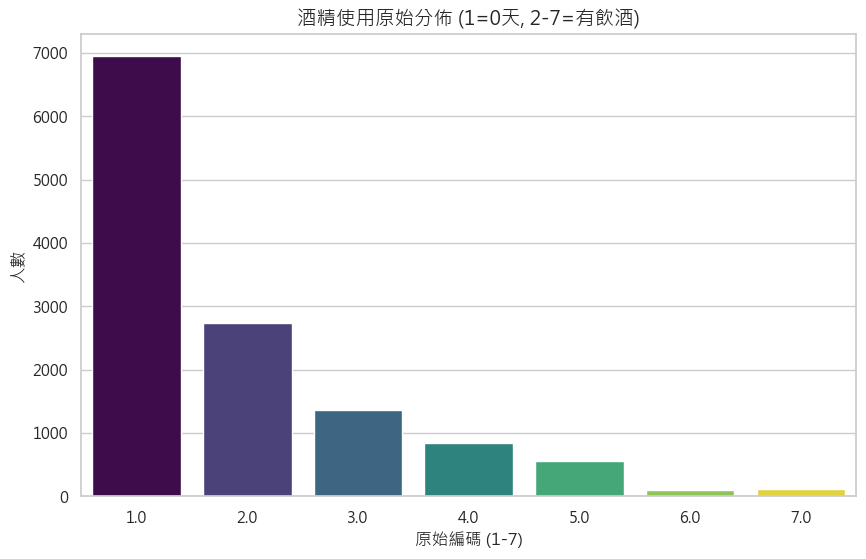

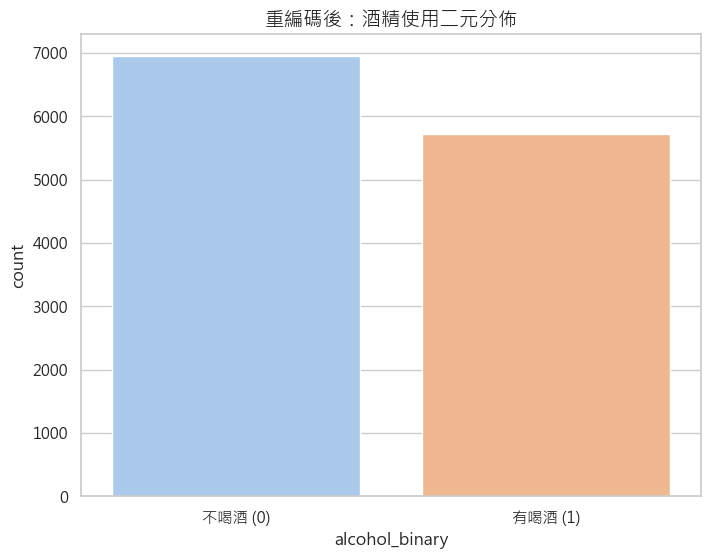

In [25]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import platform
import warnings
import numpy as np

# 忽略警告並設定中文
warnings.filterwarnings('ignore')
def set_ch_font():
    system = platform.system()
    if system == "Windows": plt.rcParams['font.sans-serif'] = ['Microsoft JhengHei']
    elif system == "Darwin": plt.rcParams['font.sans-serif'] = ['Arial Unicode MS']
    plt.rcParams['axes.unicode_minus'] = False
set_ch_font()
sns.set_theme(style="whitegrid", font=plt.rcParams['font.sans-serif'])

# 讀取 01 產出的全表
df = pd.read_csv('../Data/raw/YRBS_2007.csv')
print(f"資料讀取成功，共 {len(df)} 筆，包含 {len(df.columns)} 個欄位。")

# =====================================================================
# 🚨 關鍵點：請把下面引號裡的字，換成你用 print(df.columns.tolist()) 找到的「絕對正確名稱」
target_col = 'CurrentAlcoholUse' 
# =====================================================================

# 1. 排除酒精缺失值並建立副本
df_alc = df.dropna(subset=[target_col]).copy()

# 2. 原始分佈圖
fig_alc_raw = plt.figure(figsize=(10, 6))
sns.countplot(x=target_col, data=df_alc, palette='viridis', hue=target_col, legend=False)
plt.title('酒精使用原始分佈 (1=0天, 2-7=有飲酒)', fontsize=14)
plt.xlabel('原始編碼 (1-7)', fontsize=12)
plt.ylabel('人數', fontsize=12)

# 3. 執行二元重編碼 (Recoding)
# 定義：1 (0天) -> 0 (不喝酒) ; 2~7 -> 1 (有喝酒)
df_alc['alcohol_binary'] = df_alc[target_col].apply(lambda x: 1 if x >= 2 else 0)

# 4. 二元化分佈圖
fig_alc_bin = plt.figure(figsize=(8, 6))
sns.countplot(x='alcohol_binary', data=df_alc, palette='pastel', hue='alcohol_binary', legend=False)
plt.xticks([0, 1], ['不喝酒 (0)', '有喝酒 (1)'])
plt.title('重編碼後：酒精使用二元分佈', fontsize=14)

# 加上這行確保兩張圖都能順利顯示出來
plt.show()

In [31]:
# --- 1. 酒精變數：原始編碼頻率表 ---
print("【 由 2-1: CurrentAlcoholUse 原始變數查 】")

target_col = 'CurrentAlcoholUse'

# 包括缺失值與無效值
original_freq = df[target_col].value_counts(dropna=False).sort_index()
print(original_freq)


# --- 2. 缺失與無效值計算 ---
missing_alc = df[target_col].isnull().sum()
invalid_alc = len(df[df[target_col] > 7])

print(f"\n缺失值數量: {missing_alc}")
print(f"無效值數量: {invalid_alc}")


# --- 3. 準備編碼後的轉置比例 (Success/Failure) ---
# 🚨 新增轉換步驟：先排除缺失值，再將 1 轉換為 0 (不喝酒)，2~7 轉換為 1 (有喝酒)
df_alc = df.dropna(subset=[target_col]).copy()
df_alc['alcohol_binary'] = df_alc[target_col].apply(lambda x: 1 if x >= 2 else 0)

# 注意：這裡改用剛建立好新欄位的 df_alc 來計算
alc_stats = df_alc['alcohol_binary'].value_counts()
alc_proportions = df_alc['alcohol_binary'].value_counts(normalize=True)

summary_table_alc = pd.DataFrame({
    '人數 (Counts)': alc_stats,
    '比例 (Proportions)': alc_proportions
})

print("\n【 由 2-2: 編碼後之酒精使用統計 (0=不喝酒, 1=有喝酒) 】")
print(summary_table_alc)

【 由 2-1: CurrentAlcoholUse 原始變數查 】
CurrentAlcoholUse
1.0    6946
2.0    2735
3.0    1369
4.0     839
5.0     555
6.0     105
7.0     120
NaN    1372
Name: count, dtype: int64

缺失值數量: 1372
無效值數量: 0

【 由 2-2: 編碼後之酒精使用統計 (0=不喝酒, 1=有喝酒) 】
                人數 (Counts)  比例 (Proportions)
alcohol_binary                               
0                      6946          0.548267
1                      5723          0.451733


In [33]:
# 看看這個欄位裡最大的數字是多少
print("最大數值是:", df['CurrentAlcoholUse'].max())

最大數值是: 7.0


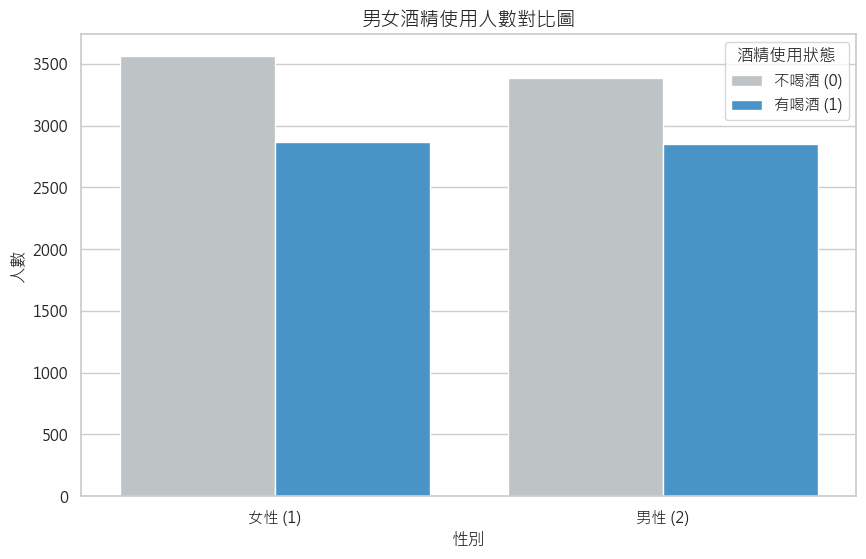

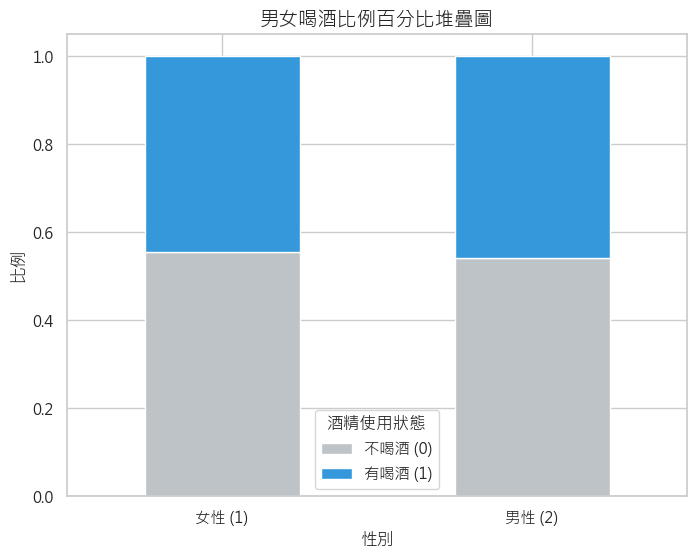

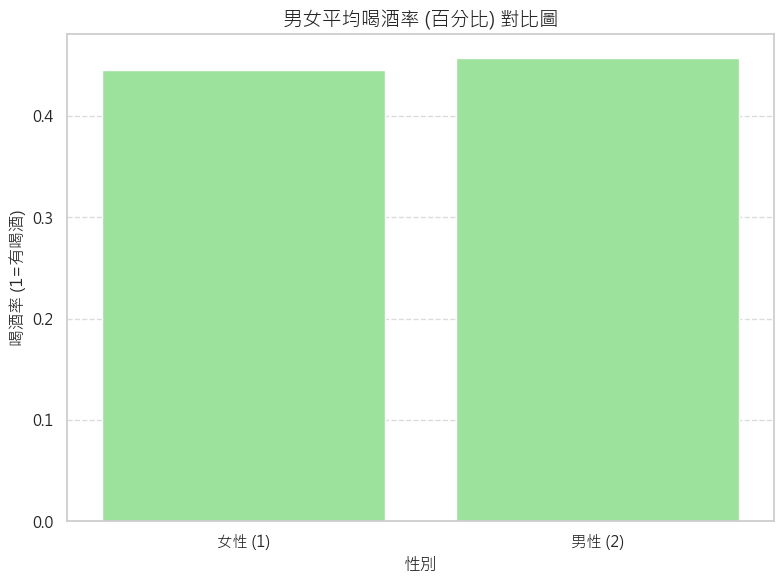

In [37]:
# 1. 排除性別缺失值
df_sex_alc = df_alc.dropna(subset=['WhatIsYourSex']).copy()

# 2. 男女喝酒人數對比圖
fig_sex_count = plt.figure(figsize=(10, 6))
# 【修正】給予兩個顏色的清單，對應 hue 的 0 和 1
sns.countplot(x='WhatIsYourSex', hue='alcohol_binary', data=df_sex_alc, palette=['#bdc3c7', '#3498db'])
plt.xticks([0, 1], ['女性 (1)', '男性 (2)'])
plt.title('男女酒精使用人數對比圖', fontsize=14)
plt.xlabel('性別', fontsize=12)
plt.ylabel('人數', fontsize=12)
plt.legend(title='酒精使用狀態', labels=['不喝酒 (0)', '有喝酒 (1)'])

# 3. 男女喝酒比例百分比堆疊圖
crosstab_prop = pd.crosstab(df_sex_alc['WhatIsYourSex'], df_sex_alc['alcohol_binary'], normalize='index')
fig_sex_stack, ax1 = plt.subplots(figsize=(8, 6))
crosstab_prop.plot(kind='bar', stacked=True, color=['#bdc3c7', '#3498db'], ax=ax1) # 顏色跟上一張圖統一
plt.xticks([0, 1], ['女性 (1)', '男性 (2)'], rotation=0)
plt.title('男女喝酒比例百分比堆疊圖', fontsize=14)
plt.xlabel('性別', fontsize=12)
plt.ylabel('比例', fontsize=12)
plt.legend(title='酒精使用狀態', labels=['不喝酒 (0)', '有喝酒 (1)'])

# 4. 男女喝酒分組長條圖
fig_sex_bar = plt.figure(figsize=(8, 6))
# 【修正】將 palette 改為 color，並將 ci 替換為新版的 errorbar
sns.barplot(x='WhatIsYourSex', y='alcohol_binary', data=df_sex_alc, errorbar=None, color='lightgreen')
plt.xticks([0, 1], ['女性 (1)', '男性 (2)'])
plt.title('男女平均喝酒率 (百分比) 對比圖', fontsize=14)
plt.xlabel('性別', fontsize=12)
plt.ylabel('喝酒率 (1=有喝酒)', fontsize=12)

# 顯示網格線與所有圖表
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout() # 自動調整間距防重疊
plt.show()

In [53]:
import scipy.stats as stats

# --- 1. 性別與酒精交叉表描述性統計 ---
contingency_table = pd.crosstab(df_sex_alc['WhatIsYourSex'], df_sex_alc['alcohol_binary'])
contingency_prop = pd.crosstab(df_sex_alc['WhatIsYourSex'], df_sex_alc['alcohol_binary'], normalize='index')

# 建立對應原本結構的統計摘要字典
desc_stats = {
    '總有效樣本數 (n)': len(df_sex_alc),
    '女性不喝酒人數': contingency_table.iloc[0, 0],
    '女性有喝酒人數': contingency_table.iloc[0, 1],
    '女性有喝酒比例 (%)': contingency_prop.iloc[0, 1] * 100,
    '男性不喝酒人數': contingency_table.iloc[1, 0],
    '男性有喝酒人數': contingency_table.iloc[1, 1],
    '男性有喝酒比例 (%)': contingency_prop.iloc[1, 1] * 100,
    '性別缺失值數量': df_alc['WhatIsYourSex'].isnull().sum()
}

print("【表 2-3：性別與酒精數據統計摘要】")
for k, v in desc_stats.items(): print(f"{k}: {v:.2f}")

# --- 2. 卡方獨立性檢定 (對應原本的 Outlier Check 統計檢驗) ---
# 用來推論「男女喝酒比例是否在統計上有顯著差異」
chi2, p_val, dof, expected = stats.chi2_contingency(contingency_table)

print("\n" + "="*50)
print(f"卡方檢定判定界線 (p-value): {p_val:.4f}")
print(f"卡方統計量 (Chi-square): {chi2:.2f}")

# 🚀 新增 1：卡方檢定假設檢查 (期望值大於 5)
# 檢查 expected 矩陣裡面是不是每一個數字都大於等於 5
if (expected >= 5).all():
    print("💡 【統計檢定假設確認】：每個細格的期望值 (Expected Frequency) 皆大於 5。完全符合卡方檢定之基本假設，檢定結果具備高度統計效力。")
else:
    print("⚠️ 【警告】：部分細格的期望值小於 5，請小心解釋卡方檢定結果。")

print("-" * 50)

# 🚀 新增 2：強而有力的結論與洞見 (Insights)
if p_val < 0.05:
    print("【基礎結論】：男女喝酒比例存在顯著差異 (p < 0.05)")
    
    # 讓程式自動判斷是誰比較高，並給出對應的洞見
    male_rate = contingency_prop.iloc[1, 1]
    female_rate = contingency_prop.iloc[0, 1]
    
    if male_rate > female_rate:
        print("🎯 【實務洞見】：數據強烈顯示，男性的飲酒比例顯著高於女性。這代表未來如果在校園推廣反對未成年飲酒的宣導，男性群體應該是首要的重點溝通對象。")
    else:
        print("🎯 【實務洞見】：數據強烈顯示，女性的飲酒比例顯著高於男性。這代表未來的校園宣導資源應更側重於女性群體。")
else:
    print("【基礎結論】：男女喝酒比例無顯著差異 (p >= 0.05)")
    print("🎯 【實務洞見】：性別並非影響飲酒行為的主要因素，未來的宣導政策可採取「性別中立」的普適性策略，或往下深挖其他變數（如年級、心理狀態）的影響。")

print("="*50 + "\n")

【表 2-3：性別與酒精數據統計摘要】
總有效樣本數 (n): 12659.00
女性不喝酒人數: 3561.00
女性有喝酒人數: 2864.00
女性有喝酒比例 (%): 44.58
男性不喝酒人數: 3381.00
男性有喝酒人數: 2853.00
男性有喝酒比例 (%): 45.77
性別缺失值數量: 10.00

卡方檢定判定界線 (p-value): 0.1847
卡方統計量 (Chi-square): 1.76
💡 【統計檢定假設確認】：每個細格的期望值 (Expected Frequency) 皆大於 5。完全符合卡方檢定之基本假設，檢定結果具備高度統計效力。
--------------------------------------------------
【基礎結論】：男女喝酒比例無顯著差異 (p >= 0.05)
🎯 【實務洞見】：性別並非影響飲酒行為的主要因素，未來的宣導政策可採取「性別中立」的普適性策略，或往下深挖其他變數（如年級、心理狀態）的影響。



📍 年級 1.0 + 女性 (1): 總人數 n=1521, 有喝酒比例=40.30%
📍 年級 1.0 + 男性 (2): 總人數 n=1560, 有喝酒比例=34.49%
📍 年級 2.0 + 女性 (1): 總人數 n=1572, 有喝酒比例=42.11%
📍 年級 2.0 + 男性 (2): 總人數 n=1550, 有喝酒比例=43.23%
📍 年級 3.0 + 女性 (1): 總人數 n=1687, 有喝酒比例=44.46%
📍 年級 3.0 + 男性 (2): 總人數 n=1477, 有喝酒比例=50.03%
📍 年級 4.0 + 女性 (1): 總人數 n=1622, 有喝酒比例=50.92%
📍 年級 4.0 + 男性 (2): 總人數 n=1611, 有喝酒比例=55.00%
📍 年級 5.0 + 女性 (1): 總人數 n=3, 有喝酒比例=100.00%
📍 年級 5.0 + 男性 (2): 總人數 n=6, 有喝酒比例=100.00%


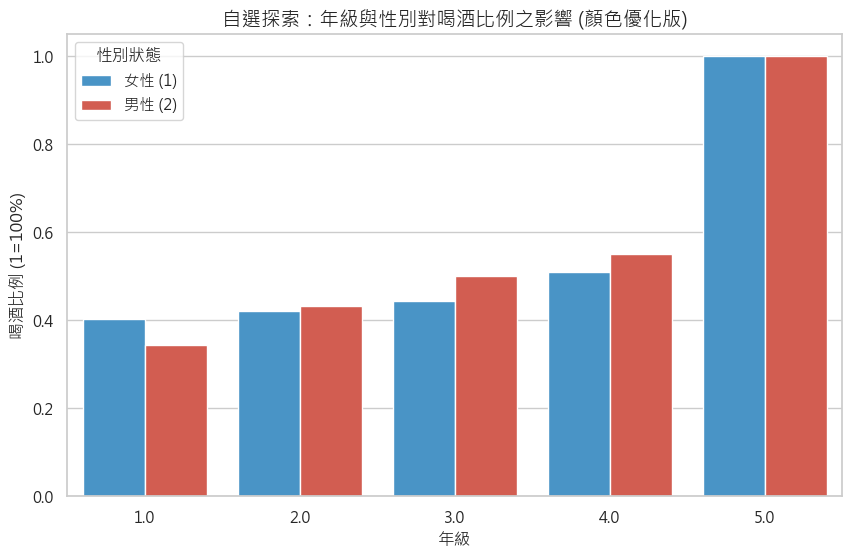

In [55]:
# --- 自選探索：年級、性別與酒精交互統計 ---
gender_col = 'WhatIsYourSex'
grade_col = 'InWhatGradeAreYou'
alc_col = 'alcohol_binary'

# 確保三個欄位都沒有缺失值
df_sub = df_alc.dropna(subset=[gender_col, grade_col]).copy()

# 1. 計算各組統計指標 (雙層迴圈)
for grade_val in sorted(df_sub[grade_col].unique()):
    for g_val, g_name in {1: "女性 (1)", 2: "男性 (2)"}.items():
        subset = df_sub[(df_sub[grade_col] == grade_val) & (df_sub[gender_col] == g_val)]
        if len(subset) > 0:
            alc_rate = subset[alc_col].mean() * 100
            print(f"📍 年級 {grade_val} + {g_name}: 總人數 n={len(subset)}, 有喝酒比例={alc_rate:.2f}%")

# 2. 視覺化分組百分比圖
plt.figure(figsize=(10, 6))
custom_palette = {1: "#3498db", 2: "#e74c3c"} # 1:女性藍色, 2:男性紅色
sns.barplot(x=grade_col, y=alc_col, hue=gender_col, data=df_sub, palette=custom_palette, ci=None)
plt.title('自選探索：年級與性別對喝酒比例之影響 (顏色優化版)', fontsize=14)
plt.xlabel('年級', fontsize=12)
plt.ylabel('喝酒比例 (1=100%)', fontsize=12)
plt.legend(title='性別狀態', labels=['女性 (1)', '男性 (2)'])
fig_gender_alc = plt.gcf()

In [57]:
# --- 自選探索：性別與酒精交互統計 (命名規則優化版) ---

# 1. 定義變數名稱與對照字典
gender_col = 'WhatIsYourSex'
grade_col = 'InWhatGradeAreYou'
alc_col = 'alcohol_binary'

# 定義命名規則 (用於 print 輸出)
gender_labels = {1: "女性 (Female, 編碼 1)", 2: "男性 (Male, 編碼 2)"}
alc_labels = {0: "不喝酒 (No/Failure, 編碼 0)", 1: "有喝酒 (Yes/Success, 編碼 1)"}

# 2. 計算整體缺失狀況
# 只要這三個欄位有一個缺失，該筆樣本就不會進入此項探索
missing_exploration = df_alc[[gender_col, alc_col, grade_col]].isnull().any(axis=1).sum()
print(f"【自選探索資料診斷】")
print(f"有效分析總樣本數: {len(df_sub)}")
print(f"缺失值排除數量: {missing_exploration} 筆\n")

# 3. 循環計算各組統計量
print(f"📋 【各分組條列式統計結果】")
for grade_val in sorted(df_sub[grade_col].unique()):
    print("=" * 60)
    print(f"🏫 【年級：{grade_val}】")
    for g_val, g_name in gender_labels.items():
        # 篩選特定年級與性別的群體
        gender_subset = df_sub[(df_sub[grade_col] == grade_val) & (df_sub[gender_col] == g_val)]
        total_n = len(gender_subset)
        
        print(f"  📍 群體：{g_name} -> 總人數: {total_n} 筆")
        for a_val, a_name in alc_labels.items():
            final_subset = gender_subset[gender_subset[alc_col] == a_val]
            count = len(final_subset)
            prop = (count / total_n * 100) if total_n > 0 else 0
            print(f"    • {a_name}: 規模 n={count} 筆, 佔該組比例={prop:.2f}%")

【自選探索資料診斷】
有效分析總樣本數: 12609
缺失值排除數量: 60 筆

📋 【各分組條列式統計結果】
🏫 【年級：1.0】
  📍 群體：女性 (Female, 編碼 1) -> 總人數: 1521 筆
    • 不喝酒 (No/Failure, 編碼 0): 規模 n=908 筆, 佔該組比例=59.70%
    • 有喝酒 (Yes/Success, 編碼 1): 規模 n=613 筆, 佔該組比例=40.30%
  📍 群體：男性 (Male, 編碼 2) -> 總人數: 1560 筆
    • 不喝酒 (No/Failure, 編碼 0): 規模 n=1022 筆, 佔該組比例=65.51%
    • 有喝酒 (Yes/Success, 編碼 1): 規模 n=538 筆, 佔該組比例=34.49%
🏫 【年級：2.0】
  📍 群體：女性 (Female, 編碼 1) -> 總人數: 1572 筆
    • 不喝酒 (No/Failure, 編碼 0): 規模 n=910 筆, 佔該組比例=57.89%
    • 有喝酒 (Yes/Success, 編碼 1): 規模 n=662 筆, 佔該組比例=42.11%
  📍 群體：男性 (Male, 編碼 2) -> 總人數: 1550 筆
    • 不喝酒 (No/Failure, 編碼 0): 規模 n=880 筆, 佔該組比例=56.77%
    • 有喝酒 (Yes/Success, 編碼 1): 規模 n=670 筆, 佔該組比例=43.23%
🏫 【年級：3.0】
  📍 群體：女性 (Female, 編碼 1) -> 總人數: 1687 筆
    • 不喝酒 (No/Failure, 編碼 0): 規模 n=937 筆, 佔該組比例=55.54%
    • 有喝酒 (Yes/Success, 編碼 1): 規模 n=750 筆, 佔該組比例=44.46%
  📍 群體：男性 (Male, 編碼 2) -> 總人數: 1477 筆
    • 不喝酒 (No/Failure, 編碼 0): 規模 n=738 筆, 佔該組比例=49.97%
    • 有喝酒 (Yes/Success, 編碼 1): 規模 n=739 筆, 佔該組比例=50.03%
🏫 【年級：4.0

In [59]:
import os

# --- 1. 建立所有必要的目錄 (統一使用大寫 Data 與 Outputs) ---
os.makedirs('../Data/Outputs/tables/', exist_ok=True)
os.makedirs('../Data/Outputs/figures/', exist_ok=True)
os.makedirs('../Data/processed/', exist_ok=True)

# --- 2. 儲存統計表格 (Tables) ---
summary_table_alc.to_csv('../Data/Outputs/tables/02_alcohol_summary.csv')
pd.DataFrame(desc_stats, index=['Value']).T.to_csv('../Data/Outputs/tables/02_gender_alcohol_summary.csv')
print("📊 統計表格已存入：../Data/Outputs/tables/")

# --- 3. 儲存視覺化圖表 (Figures) ---
save_fig_path = '../Data/Outputs/figures/'
fig_alc_raw.savefig(save_fig_path + '02_alcohol_raw_dist.png', dpi=300, bbox_inches='tight')
fig_alc_bin.savefig(save_fig_path + '02_alcohol_binary_dist.png', dpi=300, bbox_inches='tight')
fig_sex_count.savefig(save_fig_path + '02_sex_alcohol_count.png', dpi=300, bbox_inches='tight')
fig_sex_stack.savefig(save_fig_path + '02_sex_alcohol_stacked.png', dpi=300, bbox_inches='tight')
fig_sex_bar.savefig(save_fig_path + '02_sex_alcohol_barplot.png', dpi=300, bbox_inches='tight')
fig_gender_alc.savefig(save_fig_path + '02_grade_gender_alcohol_barplot.png', dpi=300, bbox_inches='tight')
print(f"🖼️  6張 男女酒精相關 EDA 圖表已存入：{save_fig_path}")

# --- 4. 儲存最終用於統計推論的資料檔 (Final Data) ---
df_sex_alc.to_csv('../Data/processed/yrbs_final.csv', index=False, encoding='utf-8-sig')
print("🚀 最終分析資料集已存入：../Data/processed/yrbs_final.csv")

📊 統計表格已存入：../Data/Outputs/tables/
🖼️  6張 男女酒精相關 EDA 圖表已存入：../Data/Outputs/figures/
🚀 最終分析資料集已存入：../Data/processed/yrbs_final.csv
